# 1. FII & DII | Net Net Investment Data

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [232]:
y_min = fdi['Gross Purchase FII'].min()
y_max = fdi['Gross Purchase FII'].max()

print(y_min,y_max)

68.79 85251.94


In [233]:
fdi = pd.read_csv('/Users/surisettivamsikrishna/Downloads/Vamsi Pc/CODES/Mark 3/Cleaned_Data_UD/FDI.csv')
nifty = pd.read_csv('/Users/surisettivamsikrishna/Downloads/Vamsi Pc/CODES/Mark 3/Cleaned_Data_UD/Nifty.csv')


In [234]:
# ---> Remove commas and convert to numeric (float)
cols_to_convert = ['Gross Purchase FII', 'Gross Sales FII', 'Net Purchase FII',
                   'Gross Purchase DII', 'Gross Sales DII', 'Net Purchase DII']

for col in cols_to_convert:
    fdi[col] = fdi[col].astype(str).str.replace(',', '', regex=True)  # ---> Remove commas
    fdi[col] = pd.to_numeric(fdi[col], errors='coerce')  # ---> Convert to float

# ---> Check data types after conversion
print(fdi.dtypes)

Unnamed: 0              int64
Date                   object
Gross Purchase FII    float64
Gross Sales FII       float64
Net Purchase FII      float64
Gross Purchase DII    float64
Gross Sales DII       float64
Net Purchase DII      float64
dtype: object


In [235]:
fdi['Net Net'] = fdi['Net Purchase FII']+fdi['Net Purchase DII']
fdi['# Net Net'] = fdi['Net Net'].shift(-1)
fdi['Change FDI']=fdi['Net Net']-fdi['# Net Net']
fdi['Change% FDI']= ((fdi['Change FDI']/fdi['# Net Net'])*100)

In [236]:
fdi.head()

,Unnamed: 0,Date,Gross Purchase FII,Gross Sales FII,Net Purchase FII,Gross Purchase DII,Gross Sales DII,Net Purchase DII,Net Net,# Net Net,Change FDI,Change% FDI
0,1,28-Feb-2025,39239.44,50878.46,-11639.02,28065.55,15756.92,12308.63,669.61,1170.55,-500.94,-42.795267
1,2,27-Feb-2025,19055.23,19611.79,-556.56,13530.17,11803.06,1727.11,1170.55,-498.32,1668.87,-334.899262
2,3,25-Feb-2025,12500.37,16029.47,-3529.10,11278.09,8247.31,3030.78,-498.32,-1101.05,602.73,-54.741383
3,4,24-Feb-2025,7905.53,14192.23,-6286.70,12552.14,7366.49,5185.65,-1101.05,-564.54,-536.51,95.034896
4,5,21-Feb-2025,10144.33,13593.48,-3449.15,12889.44,10004.83,2884.61,-564.54,596.09,-1160.63,-194.707175


In [237]:
fdi = fdi[:-1]
nifty = nifty[:-1]

In [238]:
nifty.head()

,Unnamed: 0,Index Name,Date,Open,Close,Previous day,Change pts
0,0,NIFTY 50,03 Mar 2025,22194.55,22119.30,22124.70,-5.40
1,1,NIFTY 50,28 Feb 2025,22433.40,22124.70,22545.05,-420.35
2,2,NIFTY 50,27 Feb 2025,22568.95,22545.05,22547.55,-2.50
3,3,NIFTY 50,25 Feb 2025,22516.45,22547.55,22553.35,-5.80
4,4,NIFTY 50,24 Feb 2025,22609.35,22553.35,22795.90,-242.55


In [239]:
nifty.head()
nifty['NIFTY_Change%'] = ((nifty['Close'] - nifty['Previous day']) / nifty['Previous day']* 100).round(2)




In [240]:

nifty['Date']=pd.to_datetime(nifty['Date'])

In [241]:
fdi['Date']=pd.to_datetime(fdi['Date'])
nifty['Date']=pd.to_datetime(nifty['Date'])

In [242]:
fdi.head()

,Unnamed: 0,Date,Gross Purchase FII,Gross Sales FII,Net Purchase FII,Gross Purchase DII,Gross Sales DII,Net Purchase DII,Net Net,# Net Net,Change FDI,Change% FDI
0,1,2025-02-28,39239.44,50878.46,-11639.02,28065.55,15756.92,12308.63,669.61,1170.55,-500.94,-42.795267
1,2,2025-02-27,19055.23,19611.79,-556.56,13530.17,11803.06,1727.11,1170.55,-498.32,1668.87,-334.899262
2,3,2025-02-25,12500.37,16029.47,-3529.10,11278.09,8247.31,3030.78,-498.32,-1101.05,602.73,-54.741383
3,4,2025-02-24,7905.53,14192.23,-6286.70,12552.14,7366.49,5185.65,-1101.05,-564.54,-536.51,95.034896
4,5,2025-02-21,10144.33,13593.48,-3449.15,12889.44,10004.83,2884.61,-564.54,596.09,-1160.63,-194.707175


In [243]:
nifty.head()

,Unnamed: 0,Index Name,Date,Open,Close,Previous day,Change pts,NIFTY_Change%
0,0,NIFTY 50,2025-03-03,22194.55,22119.30,22124.70,-5.40,-0.02
1,1,NIFTY 50,2025-02-28,22433.40,22124.70,22545.05,-420.35,-1.86
2,2,NIFTY 50,2025-02-27,22568.95,22545.05,22547.55,-2.50,-0.01
3,3,NIFTY 50,2025-02-25,22516.45,22547.55,22553.35,-5.80,-0.03
4,4,NIFTY 50,2025-02-24,22609.35,22553.35,22795.90,-242.55,-1.06


In [244]:
Main = pd.DataFrame()

Main = pd.merge(nifty[['Date', 'Change pts', 'NIFTY_Change%']], 
                fdi[['Date', 'Change FDI','Change% FDI','Net Net']], 
                on='Date', 
                how='inner')


In [245]:
Main.to_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/CODES/Mark 3/UNIV DATA 2/Main.csv", index=False)

In [246]:
Main.head(15)

,Date,Change pts,NIFTY_Change%,Change FDI,Change% FDI,Net Net
0,2025-02-28,-420.35,-1.86,-500.94,-42.795267,669.61
1,2025-02-27,-2.50,-0.01,1668.87,-334.899262,1170.55
2,2025-02-25,-5.80,-0.03,602.73,-54.741383,-498.32
3,2025-02-24,-242.55,-1.06,-536.51,95.034896,-1101.05
4,2025-02-21,-117.25,-0.51,-1160.63,-194.707175,-564.54
5,2025-02-20,-19.75,-0.09,519.65,679.814233,596.09
6,2025-02-19,-12.40,-0.05,-7782.31,-99.027326,76.44
7,2025-02-18,-14.20,-0.06,7036.81,856.122101,7858.75
8,2025-02-17,30.25,0.13,752.76,1088.117953,821.94
9,2025-02-14,-102.15,-0.44,-75.41,-52.154368,69.18


2. Indian Investors are completely focusing on other stocks then the Nifty Index (element[X]), so the money is flowing somewhere else find teh sector and can literally Jump in. #L2

Why I came to the conclusion:
Net Net DII's are buying and FII's are selling, but NIFTY tends to still go down no matter this, which very clearly indicates while FII's are exiting established indian blue chip, DII's are very busy buying element [X]

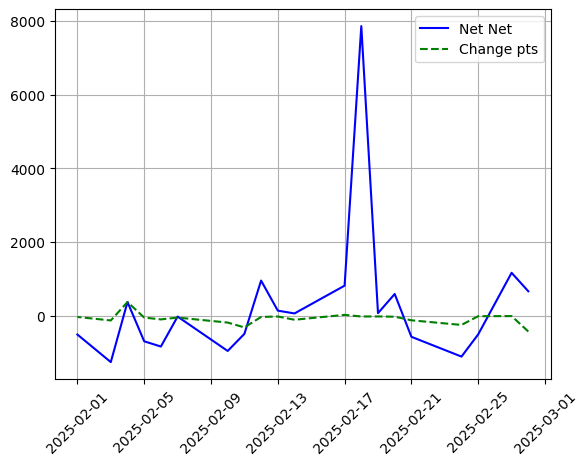

In [247]:
plt.plot(Main['Date'].iloc[:20],Main['Net Net'].iloc[:20],label='Net Net',color= 'blue',linestyle='-')
plt.plot(Main['Date'].iloc[:20],Main['Change pts'].iloc[:20],label='Change pts',color= 'green',linestyle='--')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.show()



3. Need to check broader market movement (Midcap Index, Bank Nifty, etc.).
4. What are the top foreign funds/ institutions and people who invest in Indian markets? #R
5. Haven't really thought in who are Top gainers and losers ?
6. Option market manipulation 
7. Were FIIs mostly covering shorts? → If they were closing existing short positions instead of fresh buying, the impact on the index would be minimal.

In [248]:
scaler = StandardScaler()
Main[['Net Net Std','Change pts Std']] = scaler.fit_transform(Main[['Net Net','Change pts']])
Main.head()

,Date,Change pts,NIFTY_Change%,Change FDI,Change% FDI,Net Net,Net Net Std,Change pts Std
0,2025-02-28,-420.35,-1.86,-500.94,-42.795267,669.61,0.107479,-2.061376
1,2025-02-27,-2.50,-0.01,1668.87,-334.899262,1170.55,0.341886,0.118595
2,2025-02-25,-5.80,-0.03,602.73,-54.741383,-498.32,-0.439035,0.101379
3,2025-02-24,-242.55,-1.06,-536.51,95.034896,-1101.05,-0.721073,-1.133773
4,2025-02-21,-117.25,-0.51,-1160.63,-194.707175,-564.54,-0.470022,-0.480068


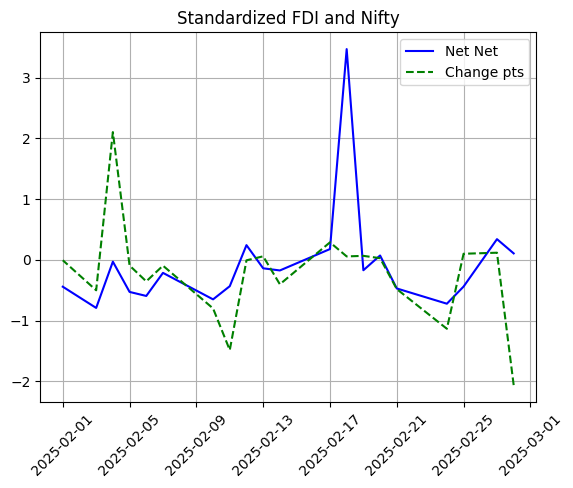

In [249]:
plt.plot(Main['Date'].iloc[:20],Main['Net Net Std'].iloc[:20],label='Net Net',color= 'blue',linestyle='-')
plt.plot(Main['Date'].iloc[:20],Main['Change pts Std'].iloc[:20],label='Change pts',color= 'green',linestyle='--')
plt.grid(True)
plt.title('Standardized FDI and Nifty')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Not at all being prpotional and infact at higher extreme conditions it's being inversly prpotional!
   VOLTATLITY raise - after X times consolidation, b/w FII&DII #L3

In [250]:
Main.head()

,Date,Change pts,NIFTY_Change%,Change FDI,Change% FDI,Net Net,Net Net Std,Change pts Std
0,2025-02-28,-420.35,-1.86,-500.94,-42.795267,669.61,0.107479,-2.061376
1,2025-02-27,-2.50,-0.01,1668.87,-334.899262,1170.55,0.341886,0.118595
2,2025-02-25,-5.80,-0.03,602.73,-54.741383,-498.32,-0.439035,0.101379
3,2025-02-24,-242.55,-1.06,-536.51,95.034896,-1101.05,-0.721073,-1.133773
4,2025-02-21,-117.25,-0.51,-1160.63,-194.707175,-564.54,-0.470022,-0.480068


# 2. US BOND YIELD RATES 

In [251]:
bond = pd.read_csv('/Users/surisettivamsikrishna/Downloads/Vamsi Pc/CODES/Mark 3/UNIV DATA/USBond Yield 10Y.csv')
bond['Yesterday DGS']=bond['DGS10'].shift(-1)
bond['Change in BYR']=bond['DGS10']-bond['Yesterday DGS']
bond = bond.iloc[:-1]
bond.head(5)



,observation_date,DGS10,Yesterday DGS,Change in BYR
0,2024-09-03,3.84,3.77,0.07
1,2024-09-04,3.77,3.73,0.04
2,2024-09-05,3.73,3.72,0.01
3,2024-09-06,3.72,3.70,0.02
4,2024-09-09,3.70,3.65,0.05


In [252]:
bond['observation_date']=pd.to_datetime(bond['observation_date'])
bond.dtypes

observation_date    datetime64[ns]
DGS10                      float64
Yesterday DGS              float64
Change in BYR              float64
dtype: object

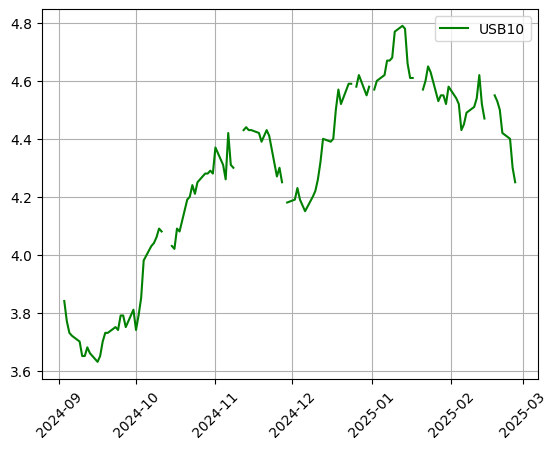

In [253]:
plt.plot(bond['observation_date'],bond['DGS10'],linestyle='-',color='Green',label='USB10')
plt.grid()
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [254]:
bond.rename(columns={'observation_date':'Date'},inplace=True)

In [255]:
bond.dtypes

Date             datetime64[ns]
DGS10                   float64
Yesterday DGS           float64
Change in BYR           float64
dtype: object

American Bond yield rates are falling down, money migth shift, exactly on 3m Mean ! #L4

In [256]:
main2=pd.concat([bond['Date'],
                 Main['Change pts'],
                 Main['Net Net'],
                 bond['DGS10'],
                 fdi['Net Purchase FII'],
                 fdi['Net Purchase DII']],
                 axis=1)
main2=main2.iloc[:-2]
main2.head()

,Date,Change pts,Net Net,DGS10,Net Purchase FII,Net Purchase DII
0,2024-09-03,-420.35,669.61,3.84,-11639.02,12308.63
1,2024-09-04,-2.50,1170.55,3.77,-556.56,1727.11
2,2024-09-05,-5.80,-498.32,3.73,-3529.10,3030.78
3,2024-09-06,-242.55,-1101.05,3.72,-6286.70,5185.65
4,2024-09-09,-117.25,-564.54,3.70,-3449.15,2884.61


In [257]:
main2.head(5)

,Date,Change pts,Net Net,DGS10,Net Purchase FII,Net Purchase DII
0,2024-09-03,-420.35,669.61,3.84,-11639.02,12308.63
1,2024-09-04,-2.50,1170.55,3.77,-556.56,1727.11
2,2024-09-05,-5.80,-498.32,3.73,-3529.10,3030.78
3,2024-09-06,-242.55,-1101.05,3.72,-6286.70,5185.65
4,2024-09-09,-117.25,-564.54,3.70,-3449.15,2884.61


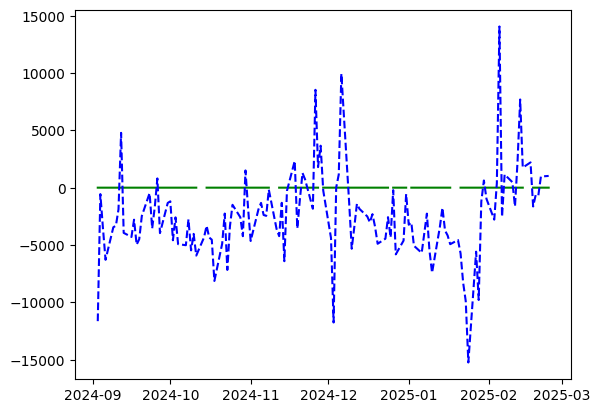

In [273]:
plt.plot(bond['Date'].iloc[:-2],main2['DGS10'],color='green',linestyle='-')
plt.plot(bond['Date'].iloc[:-2],main2['Net Purchase FII'],color='blue',linestyle='--')


In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
main2[['DGS10_S','Net Purchase FII_S']]=scaler.fit_transform(main2[['DGS10','Net Purchase FII']])
main2.head()

,Date,Change pts,Net Net,DGS10,Net Purchase FII,Net Purchase DII,DGS10_S,Net Purchase FII_S,Net Net S,Net Net S,Net Purchase DII S
0,2024-09-03,-420.35,669.61,3.84,-11639.02,3.227824,-1.355559,-2.390211,0.107479,0.107479,3.227824
1,2024-09-04,-2.50,1170.55,3.77,-556.56,-0.419064,-1.574549,0.509273,0.341886,0.341886,-0.419064
2,2024-09-05,-5.80,-498.32,3.73,-3529.10,0.030242,-1.699685,-0.268428,-0.439035,-0.439035,0.030242
3,2024-09-06,-242.55,-1101.05,3.72,-6286.70,0.772911,-1.730970,-0.989893,-0.721073,-0.721073,0.772911
4,2024-09-09,-117.25,-564.54,3.70,-3449.15,-0.020135,-1.793538,-0.247510,-0.470022,-0.470022,-0.020135


In [308]:
main2[['Net Purchase DII S']]=scaler.fit_transform(main2[['Net Purchase DII']])

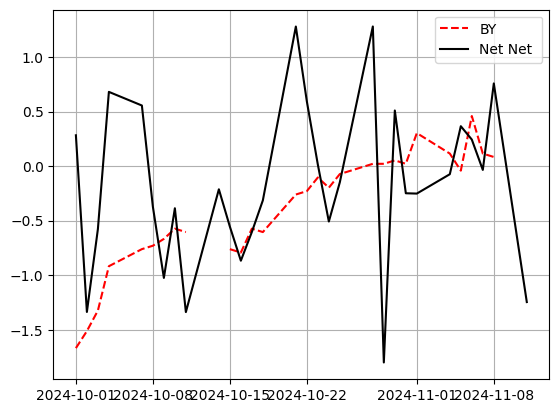

In [338]:
plt.plot(main2['Date'].iloc[20:50],main2['DGS10_S'].iloc[20:50],color='RED',linestyle='--',label='BY')
plt.plot(main2['Date'].iloc[20:50],main2['Net Net S'].iloc[20:50],color='black',linestyle='-',label='Net Net ')



plt.legend()
plt.grid()
plt.show()


VOLATALITY typically tends to be higher when Bond Yields raise! Not typically raises but VARIANCE tends to be higher!

To deep dive ----> FII, DII

In [316]:
main2.tail()

,Date,Change pts,Net Net,DGS10,Net Purchase FII,Net Purchase DII,DGS10_S,Net Purchase FII_S,Net Net S,Net Net S,Net Purchase DII S
120,2025-02-18,84.25,-880.89,4.55,-1634.98,-0.754412,0.865617,0.227128,-0.618053,-0.618053,-0.754412
121,2025-02-19,-292.95,1500.58,4.53,-620.95,-0.283128,0.803049,0.492426,0.496318,0.496318,-0.283128
122,2025-02-20,-53.60,2282.05,4.50,-688.69,0.009549,0.709196,0.474704,0.861994,0.861994,0.009549
123,2025-02-21,-81.15,1072.81,4.42,975.46,-0.980756,0.458923,0.910092,0.296150,0.296150,-0.980756
124,2025-02-24,1.15,2925.46,4.40,1029.25,-0.360784,0.396355,0.924165,1.163068,1.163068,-0.360784


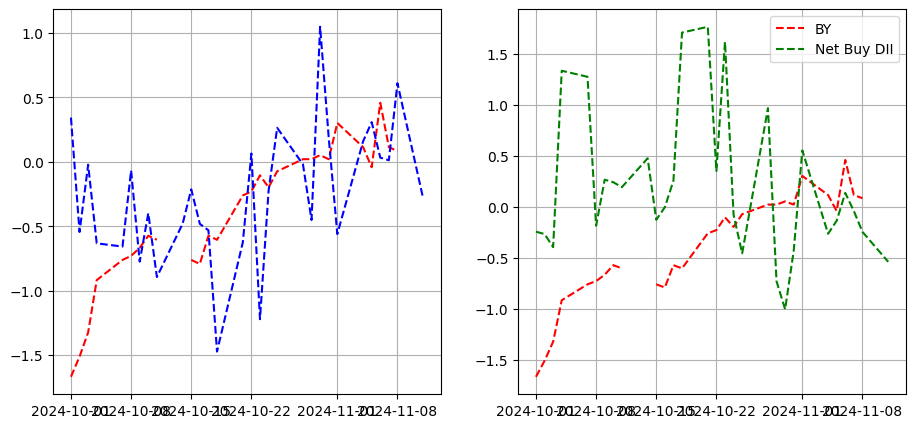

In [343]:
fig, axes=plt.subplots(1,2,figsize=(11,5))

axes[0].plot(main2['Date'].iloc[20:50],main2['DGS10_S'].iloc[20:50],color='RED',linestyle='--',label='BY')
axes[0].plot(main2['Date'].iloc[20:50],main2['Net Purchase FII_S'].iloc[20:50],color='blue',linestyle='--',label='Net Buy FII')
axes[0].grid()


axes[1].plot(main2['Date'].iloc[20:50],main2['DGS10_S'].iloc[20:50],color='RED',linestyle='--',label='BY')
axes[1].plot(main2['Date'].iloc[20:50],main2['Net Purchase DII S'].iloc[20:50],color='green',linestyle='--',label='Net Buy DII')


plt.legend()
plt.grid()
plt.show()



Clearly, fluctuations money flow from FII's and DII's based on the USB yields is key factor! The high fluctuations suggest they are more volatile and reactive. When bond yields rise, FIIs might pull out money from emerging markets, and when yields fall, they might invest more.

DIIs are also influenced but appear steadier less volatile than FIIs, meaning DIIs might be more stable and less reactive to global bond yield changes.

Naerly Volatality FII α USBY #L4

# 3. GOLD Rate 

In [345]:
gold = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/CODES/Mark 3/Cleaned_Data_UD/GOLD.csv")
gold.head()

,Unnamed: 0,Date,Price,Open,High,Low,Vol.,Change %,Yesterday Price,Change Pts
0,3,"Mar 02, 2025",2882.47,"2,867.85","2,888.15","2,867.40",0.01K,0.0119,2848.5,33.97
1,4,"Feb 28, 2025",2848.50,"2,889.00","2,896.10","2,844.10",210.56K,-1.64%,2895.9,-47.40
2,5,"Feb 27, 2025",2895.90,"2,931.40","2,935.80","2,879.00",207.65K,-0.75%,2917.8,-21.90
3,6,"Feb 26, 2025",2917.80,"2,915.60","2,926.40","2,891.00",2.05K,0.0041,2906.0,11.80
4,7,"Feb 25, 2025",2906.00,"2,955.90","2,955.90","2,884.50",5.59K,-1.48%,2949.7,-43.70


In [350]:
gold=gold.drop(columns=['Unnamed: 0','Open','High','Low'])
gold['Nifty']=nifty['Close']
gold['Nifty_Change']=nifty['Change pts']
gold['Nifty_Change %']=nifty['NIFTY_Change%']


In [369]:

gold.head()

,Date,Price,Vol.,Change %,Yesterday Price,Change Pts,Nifty,Nifty_Change,Nifty_Change %,Gold price S,Nifty price S
0,"Mar 02, 2025",2882.47,0.01K,0.0119,2848.5,33.97,22119.30,-5.40,-0.02,1.457356,-2.419483
1,"Feb 28, 2025",2848.50,210.56K,-1.64%,2895.9,-47.40,22124.70,-420.35,-1.86,1.135892,-2.411883
2,"Feb 27, 2025",2895.90,207.65K,-0.75%,2917.8,-21.90,22545.05,-2.50,-0.01,1.584446,-1.820277
3,"Feb 26, 2025",2917.80,2.05K,0.0041,2906.0,11.80,22547.55,-5.80,-0.03,1.791689,-1.816758
4,"Feb 25, 2025",2906.00,5.59K,-1.48%,2949.7,-43.70,22553.35,-242.55,-1.06,1.680024,-1.808595


In [368]:
scaler=StandardScaler()

gold[['Gold price S','Nifty price S']]=scaler.fit_transform(gold[['Price','Nifty']])

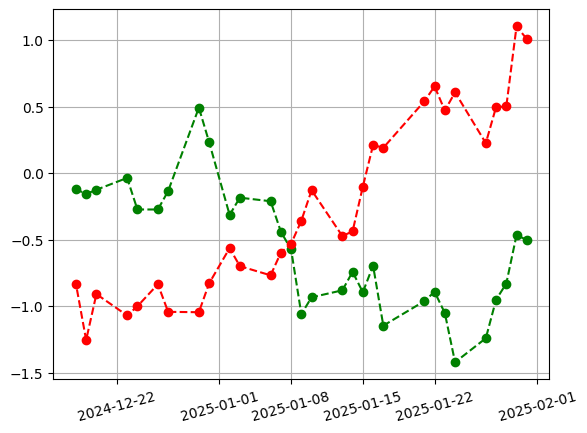

In [388]:
plt.plot(gold['Date'].iloc[20:50],gold['Nifty price S'].iloc[20:50],marker='o',color='Green',linestyle='--',label='BY')
plt.plot(gold['Date'].iloc[20:50],gold['Gold price S'].iloc[20:50],marker='o',color='RED',linestyle='--',label='BY')
plt.xticks(rotation=15)
plt.grid()
plt.show()


It's a pretty established FACT, GOLD ⍺ 1/ NIFTY, or any Index! But here's what is interesting !!
1. Nifty is consolidating and Gold is volatile, small moves are observed in NIFTY
2. When both are consolidtaingwith data points[X]----> Anticipated BIG MOVE!! 


Very Keen INTERSETING is last week GOLD ∝ NIFTY | Have to check!

In [393]:
Rudol = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/CODES/Mark 3/Cleaned_Data_UD/DINR.csv")
Rudol

,Unnamed: 0,Date,Price,Change %,Previous_day,Change Pts
0,0,03-03-2025,87.270,-0.22%,87.466,-0.196
1,1,28-02-2025,87.466,0.16%,87.330,0.136
2,2,27-02-2025,87.330,0.25%,87.113,0.217
3,3,26-02-2025,87.113,-0.02%,87.130,-0.017
4,4,25-02-2025,87.130,0.54%,86.660,0.470
...,...,...,...,...,...,...
126,126,06-09-2024,83.985,0.03%,83.961,0.024
127,127,05-09-2024,83.961,0.00%,83.960,0.001
128,128,04-09-2024,83.960,0.01%,83.950,0.010
129,129,03-09-2024,83.950,0.08%,83.880,0.070
